# Week 4 – Supervised Learning: Regression Model

## Predicting California Housing Prices

### Objective

The objective of this project is to build and compare multiple regression models to predict house prices using the California Housing dataset.

The following regression algorithms will be implemented during this project:

- Linear Regression
- Ridge Regression
- Random Forest Regressor

The models will be evaluated using:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- R² Score

Finally, the best-performing model will be selected based on the evaluation results.

In [1]:
# Import libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing

from sklearn.model_selection import train_test_split

print("Libraries imported successfully!")

Libraries imported successfully!


## Step 1 – Load Dataset

The California Housing dataset is provided by Scikit-learn.

It contains information about different districts in California, including:

- Average income
- House age
- Number of rooms
- Population
- Latitude
- Longitude

The target variable is the median house value.

In [2]:
# Load California Housing dataset

housing = fetch_california_housing()

print("Dataset loaded successfully!")

Dataset loaded successfully!


##  Step 2 – Create DataFrame

To make the dataset easier to explore and manipulate, we convert it into a Pandas DataFrame.

In [3]:
# Create DataFrame

df = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

df["HouseValue"] = housing.target

print("DataFrame created successfully!")

DataFrame created successfully!


##  Step 3 – Display Dataset

Let's display the first five rows of the dataset to understand its structure.

In [4]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HouseValue
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   HouseValue  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [6]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HouseValue
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


##  Step 6 – Check Missing Values

Before training any regression model, it is important to verify whether the dataset contains missing values.

In [7]:
df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
HouseValue    0
dtype: int64

##  Step 7 – Select Features and Target

The dataset is divided into:

- Features (X): Input variables used for prediction.
- Target (y): HouseValue, which represents the median house value.

In [8]:
# Features and Target

X = df.drop("HouseValue", axis=1)

y = df["HouseValue"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (20640, 8)
Target Shape: (20640,)


##  Step 8 – Split Dataset

The dataset is divided into:

- 80% Training Data
- 20% Testing Data

The training set is used to train the regression models, while the testing set is used to evaluate their performance.

In [9]:
# Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Labels :", y_train.shape)
print("Testing Labels  :", y_test.shape)

Training Features: (16512, 8)
Testing Features : (4128, 8)
Training Labels : (16512,)
Testing Labels  : (4128,)


---

#  Day 2 – Linear Regression Model

## Objective

In this section, we will build our first regression model using **Linear Regression**.

The model will learn the relationship between the housing features and the house value, then predict house prices on unseen data.

Finally, we will evaluate the model using standard regression metrics.

In [10]:
# Import Linear Regression and Evaluation Metrics

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Regression libraries imported successfully!")

Regression libraries imported successfully!


##  Step 9 – Train Linear Regression Model

The Linear Regression model is trained using the training dataset created during Day 1.

In [11]:
# Create Linear Regression model

linear_model = LinearRegression()

# Train the model

linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


##  Step 10 – Make Predictions

The trained model is now used to predict house prices for the testing dataset.

In [12]:
# Predict house prices

y_pred = linear_model.predict(X_test)

print("Predictions generated successfully!")

Predictions generated successfully!


##  Step 11 – Model Evaluation

The Linear Regression model will be evaluated using:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- R² Score

These metrics help us understand how accurately the model predicts house prices.

In [13]:
# Calculate regression metrics

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error : {mae:.4f}")

print(f"Mean Squared Error  : {mse:.4f}")

print(f"R² Score            : {r2:.4f}")

Mean Absolute Error : 0.5332
Mean Squared Error  : 0.5559
R² Score            : 0.5758


##  Step 12 – Actual vs Predicted Values

The scatter plot below compares the actual house prices with the predicted values.

If the predictions are accurate, the points should appear close to the diagonal trend.

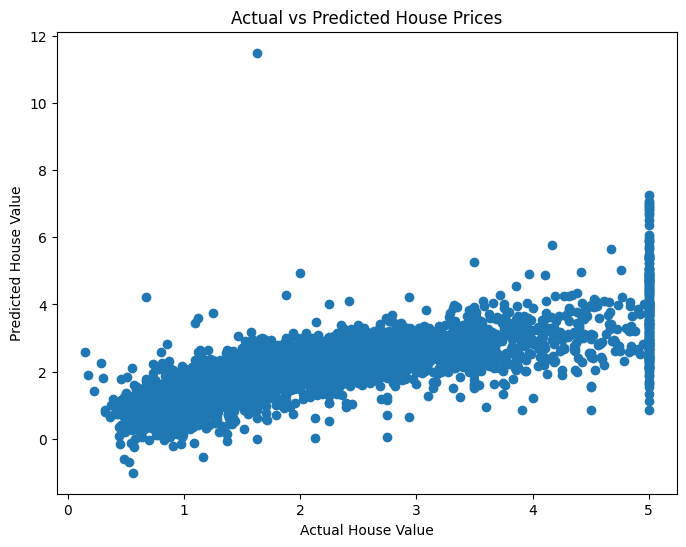

In [14]:
# Actual vs Predicted Scatter Plot

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual House Value")

plt.ylabel("Predicted House Value")

plt.title("Actual vs Predicted House Prices")

plt.savefig("linear_regression_prediction.png")

plt.show()

In [15]:
# Compare Actual vs Predicted

results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

results.head(10)

,Actual,Predicted
0,0.47700,0.719123
1,0.45800,1.764017
2,5.00001,2.709659
3,2.18600,2.838926
4,2.78000,2.604657
5,1.58700,2.011754
6,1.98200,2.645500
7,1.57500,2.168755
8,3.40000,2.740746
9,4.46600,3.915615



### Tasks Completed

- Imported Linear Regression
- Trained the regression model
- Generated predictions
- Calculated MAE
- Calculated MSE
- Calculated R² Score
- Visualized Actual vs Predicted values
- Compared sample predictions

The first regression model has been successfully implemented and evaluated.

---

#  Day 3 – Ridge Regression Model

## Objective

In this section, we will implement the **Ridge Regression** model.

Ridge Regression is an improved version of Linear Regression that reduces overfitting by applying regularization. It is especially useful when features are highly correlated.

The model will be evaluated using:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- R² Score

The results will later be compared with the other regression models.

In [16]:
# Import Ridge Regression

from sklearn.linear_model import Ridge

print("Ridge Regression imported successfully!")

Ridge Regression imported successfully!


##  Step 14 – Train Ridge Regression Model

We now train the Ridge Regression model using the training dataset prepared during Day 1.

In [17]:
# Create Ridge Regression model

ridge_model = Ridge(alpha=1.0)

# Train model

ridge_model.fit(X_train, y_train)

print("Ridge Regression model trained successfully!")

Ridge Regression model trained successfully!


## Step 15 – Make Predictions

The trained Ridge Regression model is used to predict house prices for the testing dataset.

In [18]:
# Predict house prices

ridge_pred = ridge_model.predict(X_test)

print("Predictions generated successfully!")

Predictions generated successfully!


In [19]:
# Calculate evaluation metrics

ridge_mae = mean_absolute_error(y_test, ridge_pred)

ridge_mse = mean_squared_error(y_test, ridge_pred)

ridge_r2 = r2_score(y_test, ridge_pred)

print(f"Mean Absolute Error : {ridge_mae:.4f}")

print(f"Mean Squared Error  : {ridge_mse:.4f}")

print(f"R² Score            : {ridge_r2:.4f}")

Mean Absolute Error : 0.5332
Mean Squared Error  : 0.5558
R² Score            : 0.5759


##  Step 17 – Actual vs Predicted Values

The scatter plot below compares the actual house prices with the values predicted by the Ridge Regression model.

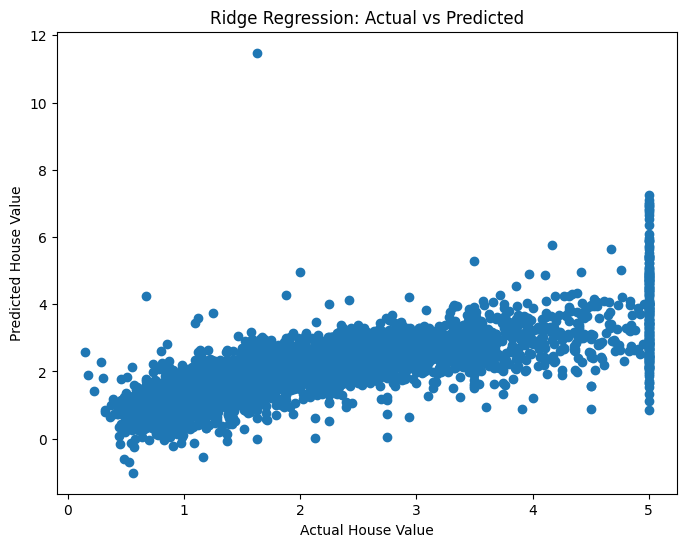

In [21]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, ridge_pred)

plt.xlabel("Actual House Value")

plt.ylabel("Predicted House Value")

plt.title("Ridge Regression: Actual vs Predicted")



plt.show()

##  Step 18 – Sample Predictions

The table below compares actual house prices with the values predicted by the Ridge Regression model.

In [22]:
ridge_results = pd.DataFrame({

    "Actual": y_test.values,

    "Predicted": ridge_pred

})

ridge_results.head(10)

,Actual,Predicted
0,0.47700,0.719240
1,0.45800,1.763951
2,5.00001,2.709092
3,2.18600,2.838976
4,2.78000,2.604768
5,1.58700,2.011791
6,1.98200,2.645591
7,1.57500,2.168770
8,3.40000,2.740131
9,4.46600,3.915568


In [23]:
comparison = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Ridge Regression"
    ],

    "MAE":[
        mae,
        ridge_mae
    ],

    "MSE":[
        mse,
        ridge_mse
    ],

    "R² Score":[
        r2,
        ridge_r2
    ]

})

comparison

,Model,MAE,MSE,R² Score
0,Linear Regression,0.533200,0.555892,0.575788
1,Ridge Regression,0.533204,0.555803,0.575855


## MY Observation

Both Linear Regression and Ridge Regression performed well on the California Housing dataset.

Ridge Regression introduces regularization, which can reduce overfitting and improve model stability.

The final regression model, Random Forest Regressor, will be implemented next before selecting the best-performing model.